In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df=pd.read_csv("data/SampleSuperStoreCleaned.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [6]:
df["Order Date"].head()

0    2016-11-08
1    2016-11-08
2    2016-06-12
3    2015-10-11
4    2015-10-11
Name: Order Date, dtype: str

In [8]:
df["Order Date"]=pd.to_datetime(df["Order Date"],errors="coerce")

In [9]:
df["Order Date"].dtype

dtype('<M8[us]')

In [11]:
df_time=df.copy()
df_time=df_time.set_index("Order Date")
df_time.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2016-11-08,1,CA-2016-152156,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2016-11-08,2,CA-2016-152156,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2016-06-12,3,CA-2016-138688,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
2015-10-11,4,US-2015-108966,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
2015-10-11,5,US-2015-108966,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
daily_sales=df_time["Sales"].resample("D").sum()
daily_sales.head()


Order Date
2014-01-03      16.448
2014-01-04     288.060
2014-01-05      19.536
2014-01-06    4407.100
2014-01-07      87.158
Freq: D, Name: Sales, dtype: float64

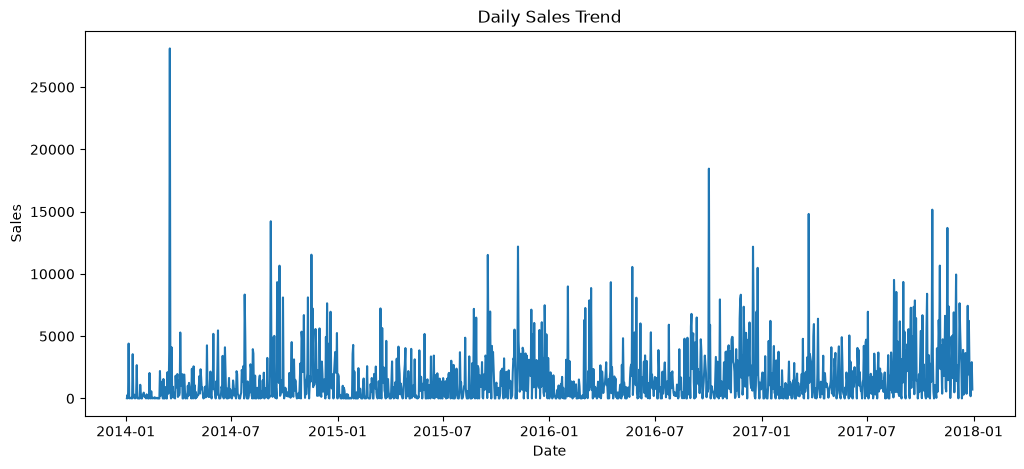

In [13]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [14]:
weekly_sales=df_time["Sales"].resample("W").sum()
weekly_sales.head()

Order Date
2014-01-05     324.044
2014-01-12    4599.572
2014-01-19    4509.127
2014-01-26    3842.388
2014-02-02    1642.310
Freq: W-SUN, Name: Sales, dtype: float64

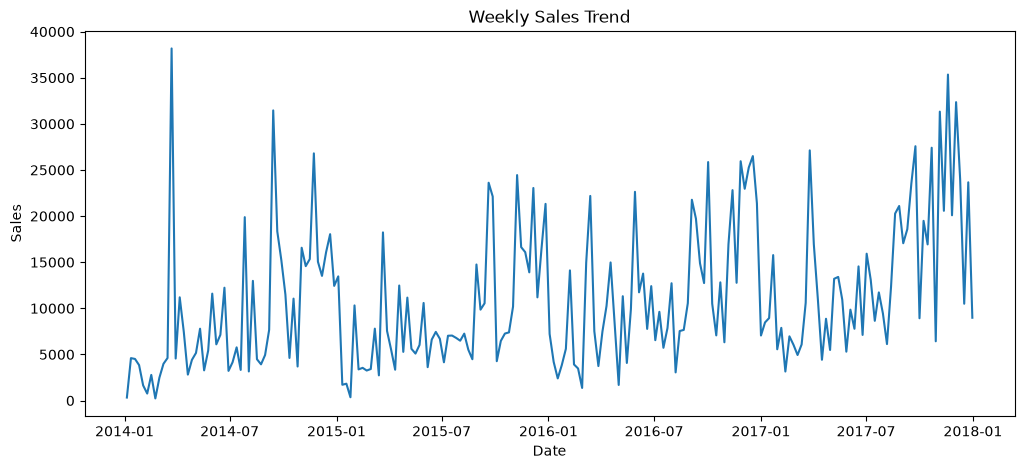

In [15]:
plt.figure(figsize=(12,5))
plt.plot(weekly_sales)
plt.title("Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [16]:
monthly_sales = df_time["Sales"].resample("ME").sum()
monthly_sales.head()

Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64

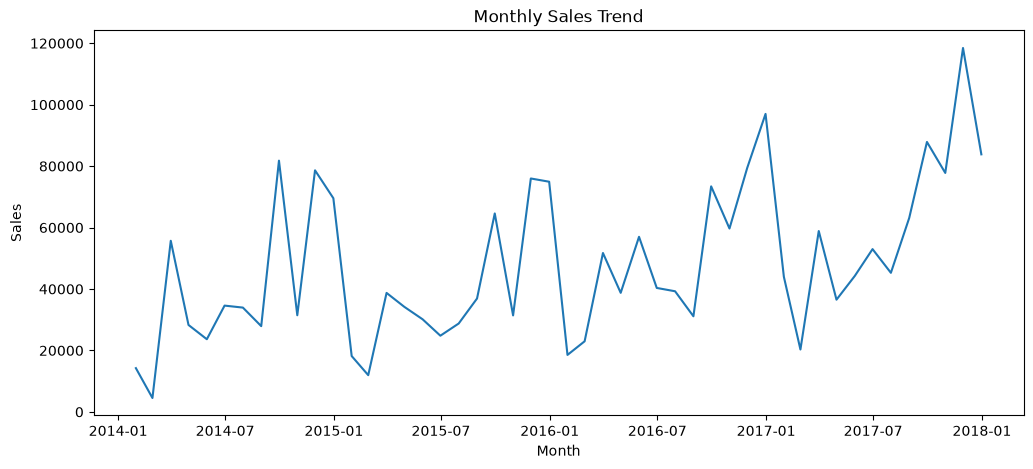

In [17]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [18]:
monthly_sales_ma = monthly_sales.rolling(window=3).mean()

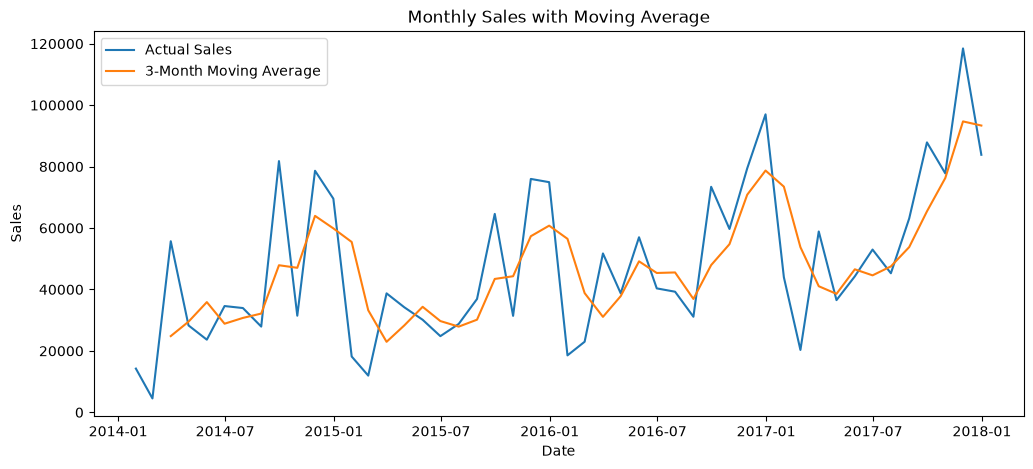

In [19]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales, label="Actual Sales")
plt.plot(monthly_sales_ma, label="3-Month Moving Average")
plt.title("Monthly Sales with Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

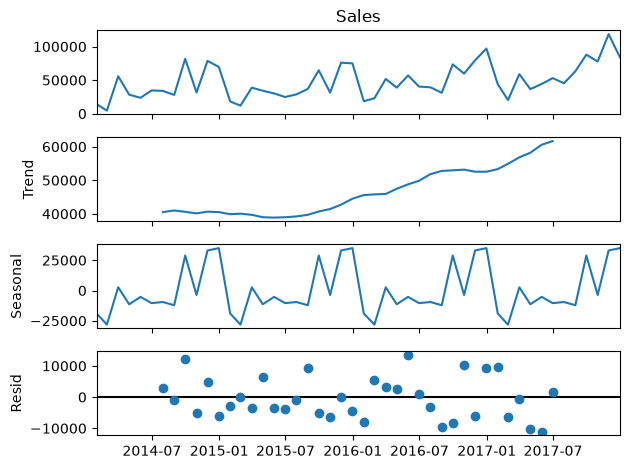

In [21]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)
decomposition.plot()
plt.show()

In [22]:
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [23]:
furniture_sales = df[df["Category"] == "Furniture"]["Sales"]
technology_sales = df[df["Category"] == "Technology"]["Sales"]

In [24]:
t_stat, p_value = stats.ttest_ind(
    furniture_sales,
    technology_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -3.6721193135511303
P-value: 0.00024559450867698803


## Interpretation:
* If the p-value is less than 0.05, we reject the null hypothesis.
* If the p-value is greater than or equal to 0.05, we fail to reject the null hypothesis.
Therefore, based on the obtained p-value, we can determine whether there is a statistically significant difference in sales between Furniture and Technology.

In [25]:
customer_data = df.groupby("Customer ID").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum",
    "Order ID": "nunique"
}).reset_index()

In [26]:
customer_data.rename(
    columns={"Order ID": "Number_of_Orders"},
    inplace=True
)

In [27]:
customer_data.head()

,Customer ID,Sales,Profit,Quantity,Number_of_Orders
0,AA-10315,5563.560,-362.8825,30,5
1,AA-10375,1056.390,277.3824,41,9
2,AA-10480,1790.512,435.8274,36,4
3,AA-10645,5086.935,857.8033,64,6
4,AB-10015,886.156,129.3465,13,3


In [28]:
features = customer_data[
    ["Sales", "Profit", "Quantity", "Number_of_Orders"]
]

In [29]:
features.head()

,Sales,Profit,Quantity,Number_of_Orders
0,5563.560,-362.8825,30,5
1,1056.390,277.3824,41,9
2,1790.512,435.8274,36,4
3,5086.935,857.8033,64,6
4,886.156,129.3465,13,3


In [31]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [32]:
scaled_features[:5]

array([[ 1.01511197, -0.81016078, -0.71530858, -0.51642886],
       [-0.70059002, -0.09373862, -0.27224696,  1.05264427],
       [-0.4211387 ,  0.08355286, -0.47363861, -0.90869715],
       [ 0.83367962,  0.55572131,  0.6541546 , -0.12416058],
       [-0.76539139, -0.25938287, -1.40004016, -1.30096543]])

In [49]:
import warnings
warnings.filterwarnings("ignore")

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

print(inertia)

[1966.989141633419, 1523.2097854429348, 1311.5316170883514, 1140.0719016804144, 984.4219740352462, 841.0021991668874, 765.8230126569946, 720.0944833795091, 673.7005886208163]


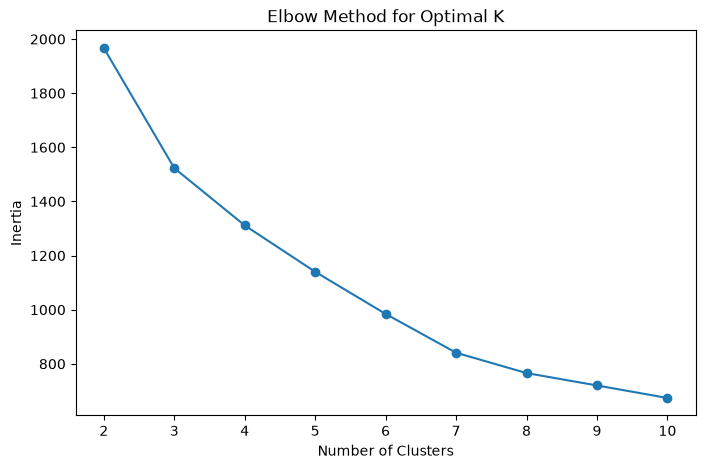

In [37]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [50]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(scaled_features)

In [51]:
customer_data.head()

,Customer ID,Sales,Profit,Quantity,Number_of_Orders,Cluster
0,AA-10315,5563.560,-362.8825,30,5,0
1,AA-10375,1056.390,277.3824,41,9,0
2,AA-10480,1790.512,435.8274,36,4,3
3,AA-10645,5086.935,857.8033,64,6,0
4,AB-10015,886.156,129.3465,13,3,3


In [52]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

In [53]:
pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = customer_data["Cluster"]

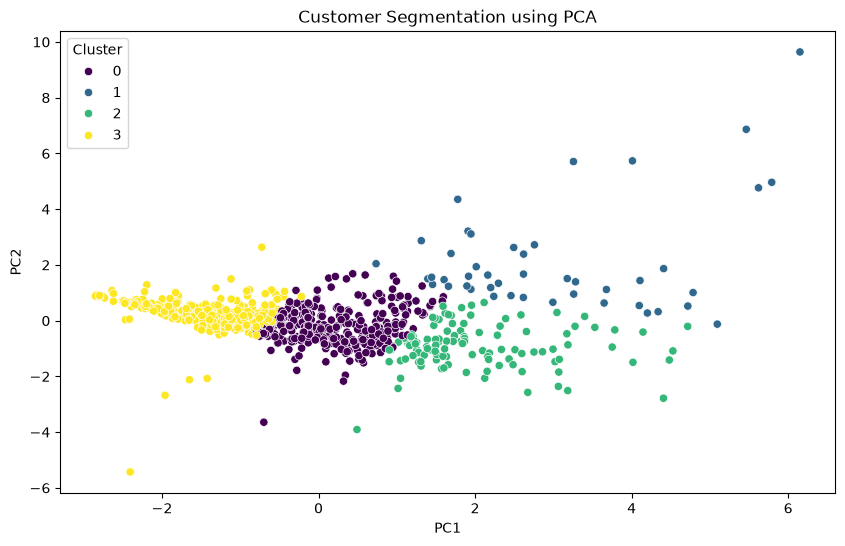

In [54]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segmentation using PCA")
plt.show()

In [55]:
cluster_profile = customer_data.groupby("Cluster").agg({
    "Sales": "mean",
    "Profit": "mean",
    "Quantity": "mean",
    "Number_of_Orders": "mean"
})

cluster_profile

,Sales,Profit,Quantity,Number_of_Orders
Cluster,,,,
0,2874.505417,328.128142,51.235650,7.018127
1,9951.135073,2502.723953,67.977778,7.800000
2,4583.976467,421.793146,87.070175,9.912281
3,1238.828950,56.368350,26.168317,3.976898


## Cluster Profiling and Recommendations

### Cluster 0 – Moderate-value Customers
These customers generate moderate sales and profit with regular orders.
**Recommendation:** Use loyalty points, personalized offers and cross-selling campaigns to increase customer value.

### Cluster 1 – High-value Customers
These customers have the highest average sales and profit.
**Recommendation:** Target them with VIP loyalty programs, premium products, exclusive offers and personalized marketing.

### Cluster 2 – Frequent/Quantity-focused Customers
These customers have high order frequency and purchase quantity.
**Recommendation:** Offer bulk discounts, product bundles and repeat-order incentives to improve retention.

### Cluster 3 – Low-value Customers
These customers have relatively low sales, profit and order frequency.
**Recommendation:** Use targeted promotions, introductory discounts and product recommendations to increase engagement and purchase frequency.

In [60]:
X=df[["Quantity","Discount"]]
y=df["Sales"]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [62]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 52.74,-128.73]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Quantity','Discount']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,46.95
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [63]:
y_pred = model.predict(X_test)

In [64]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.03625634814946299


In [65]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 274.98422630547105


In [66]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 754.5081631815635


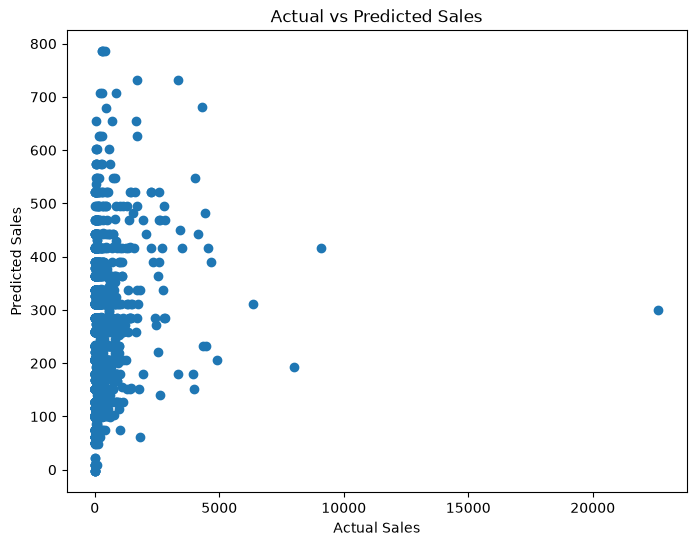

In [67]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [68]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance["Absolute_Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Importance
1,Discount,-128.734476,128.734476
0,Quantity,52.740244,52.740244


In [69]:
feature_importance.head(3)

,Feature,Coefficient,Absolute_Importance
1,Discount,-128.734476,128.734476
0,Quantity,52.740244,52.740244


In [70]:
X=df[["Quantity","Discount","Profit"]]

## Conclusion
1.Sales showed a particular trend over time.
2.Monthly resampling helped identify long-term patterns.
3.Moving averages helped smooth fluctuations.
4.Statistical testing was used to compare sales groups.
5.K-Means identified distinct customer segments.
6.PCA helped visualize the segments.
7.Linear Regression was used to predict sales.
8.R², MAE and RMSE were used for evaluation.
9.The most influential features were identified from model coefficients